# Chain Using LangGraph
In this section we will see how we can build a simple chain using Langgraph that uses 4 important concepts
* How to use chat messages as our graph state
* How to use chat models in graph nodes
* How to bind tools to our LLM in chat models
* How to execute the tools call in our graph nodes

In [35]:
from dotenv import load_dotenv
load_dotenv() 

import os 
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

How to use chat messages as our graph state

Message 

We can use messages which can be used to capture different roles within a conversation. LangChain has various message types
including Human Message, AlMessage, SystemMessage and ToolMessage. These represent a message from the user, from chat model,
for the chat model to instruct behavior, and from a tool call.

Every message have these important components.
* content - content of the message
* name - Specify the name of author
* response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AlMessages)

In [36]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint 

messages = [AIMessage(content=f"Please tell me how can I help me",name="LLMModel")] 
messages.append(HumanMessage(content=f"I want to lear codeing ",name="Krish"))
 
messages.append(AIMessage(content=f"Which programming language youwant to learn",name="LLMModel")) 

for messages in messages:
    messages.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help me
================================ Human Message =================================
Name: Krish

I want to lear codeing 
================================== Ai Message ==================================
Name: LLMModel

Which programming language youwant to learn


# Chat models

We can use the sequence of message as input with the chatmodels using LLM's and OPENAI.

In [37]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="openai/gpt-oss-20b",temperature=0)
llm.invoke("Hi")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi". We need to respond politely. Probably a friendly greeting.'}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 72, 'total_tokens': 108, 'completion_time': 0.037006498, 'completion_tokens_details': {'reasoning_tokens': 18}, 'prompt_time': 0.003400503, 'prompt_tokens_details': None, 'queue_time': 0.345723624, 'total_time': 0.040407001}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_976a85d17a', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0b324-0dd8-76f0-bd66-771b1260ef3b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 36, 'total_tokens': 108, 'output_token_details': {'reasoning': 18}})

# Router 

We can think of this as a router, where the chat model
routes between a direct response or a tool call based
upon the user input.

This is a simple example of an agent, where the LLM is
directing the control flow either by calling a tool or just
responding directly.

# Tool

Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the natural language input and this will
return an output that matches the tool's schema

In [38]:
def add(a:int,b:int)-> int:
    """ Add a and b 
    Args:
        a (int): Frist int
        b (int): second int

    Returns:
        int: _description_
    """
    return a+b 
    
        

In [39]:
llm 

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000154522A00D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000015452237BD0>, model_name='openai/gpt-oss-20b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [40]:
## Binding tools with llm

llm_with_tools =  llm.bind_tools([add])

tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2",name="Rishabh")])

### Using message as state


In [41]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

### Reducers
Now, we have a minor problem!
As we discussed, each node will return a new value for our state key messages.

But, this new value will override the prior messages value.

As our graph runs, we want to append messages to our messages state key.

We can use reducer functions to address this.
Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built add_messages reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [42]:
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

### Reducers with add_messages

In [43]:
initial_messages = [AIMessage(content=f"Please tell me how can I help me",name="LLMModel")] 
initial_messages.append(HumanMessage(content=f"I want to lear codeing ",name="Krish"))

In [44]:
ai_message = AIMessage(content=f"Which programming language you want to learn",name='LLMModel')

In [45]:
ai_message

AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [46]:
### Reduceras add_message is to instend of override
add_messages(initial_messages,ai_message)

[AIMessage(content='Please tell me how can I help me', additional_kwargs={}, response_metadata={}, name='LLMModel', id='6d362a5f-f69a-4ea7-a94b-c2b8d3a380dc', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to lear codeing ', additional_kwargs={}, response_metadata={}, name='Krish', id='2e9fe15e-d588-4164-99ab-c39822cedc31'),
 AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='77450687-3899-4341-ad66-76f1d2bcf13d', tool_calls=[], invalid_tool_calls=[])]

In [47]:
### chatbot node functionality 
def llm_tool(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}




In [48]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Use State (not StateGraph)
builder = StateGraph(State)
builder.add_node("llm_tool", llm_tool)  
builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

graph = builder.compile()


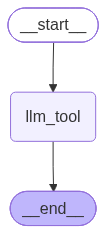

In [49]:
graph= builder.compile() 
display(Image(graph.get_graph().draw_mermaid_png()))

In [50]:
from langchain_core.messages import HumanMessage

### invocation
messages = graph.invoke({"messages": [HumanMessage(content="What is 2 plus 2")]})

for message in messages["messages"]:
    message.pretty_print()


================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================

2 plus 2 equals **4**.


In [53]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


In [56]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# 1. Define the tools list
tools = [add]

# 2. Build the graph
builder = StateGraph(State)

# 3. Add nodes
builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))

# 4. Add edges
builder.add_edge(START, "llm_tool")

# Conditional edge: routes to "tools" if tool called, otherwise routes to END
builder.add_conditional_edges(
    "llm_tool",
    tools_condition,
)

# Loop back to llm_tool after tool execution so the model can generate the final answer
builder.add_edge("tools", "llm_tool")

# 5. Compile the graph
graph_builder = builder.compile()


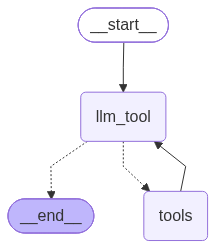

In [57]:
from IPython.display import Image, display

display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [59]:
from langchain_core.messages import HumanMessage

response = graph_builder.invoke({"messages": [HumanMessage(content="what is Deep Learning?")]})

for msg in response["messages"]:
    msg.pretty_print()


================================ Human Message =================================

what is Deep Learning?
================================== Ai Message ==================================

**Deep Learning** is a subfield of machine learning that uses artificial neural networks with many layers—hence “deep”—to model complex patterns in data. These networks learn hierarchical representations: lower layers capture simple features (e.g., edges in images, phonemes in audio), while higher layers combine those into more abstract concepts (e.g., faces, objects, or sentiment).  

Key points:

| Feature | Description |
|---------|-------------|
| **Neural Networks** | Networks of interconnected “neurons” that process information via weighted connections. |
| **Depth** | Multiple hidden layers (often dozens or hundreds) allow the model to learn increasingly abstract features. |
| **Learning** | Parameters (weights) are optimized by back‑propagation and gradient‑based methods (e.g., SGD, Adam). |
| 